<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Disk_Magnet_Field_MagPyLib_and_PyVista_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev libopengl0 libgl1 libegl1 libxrender1
!uv pip install -q "numpy>=2.0" "pyvista[jupyter]" magpylib ipywidgets "cupy-cuda12x>=13.0,<14"

In [7]:
"""Render an irregularly sampled magnetic field around a disk magnet.

CuPy performs the magnetic field calculation on the NVIDIA GPU. Magpylib
provides the magnetic source representation and optional sparse CPU reference
checks. PyVista/VTK renders the final collision-managed vector glyphs.

The external field of a uniformly magnetized finite cylinder is evaluated with
GPU-accelerated bound-surface-charge quadrature. Top, bottom, and cylindrical
side surfaces are discretized into magnetic-charge panels. This supports an
arbitrary homogeneous magnetization direction.
"""

import itertools
import sys
import time

import cupy as cp
import magpylib as magpy
import numpy as np
import pyvista as pv
from google.colab import output


# -----------------------------------------------------------------------------
# CONTROL KNOBS - COLAB / PYVISTA
# -----------------------------------------------------------------------------

JUPYTER_BACKEND = "html"

PLOT_WINDOW_SIZE = (1100, 800)

BACKGROUND_COLOR = "white"
GRID_COLOR = "lightgray"
LABEL_COLOR = "black"

FIELD_COLORMAP = "turbo"

SHOW_GRID = True
SHOW_GRID_LABELS = False
SHOW_ORIENTATION_AXES = False
SHOW_FIELD_COLORBAR = True

CAMERA_POSITION_CM = (11.0, -13.0, 9.0)
CAMERA_FOCAL_POINT_CM = (0.0, 0.0, 0.0)
CAMERA_VIEW_UP = (0.0, 0.0, 1.0)


# -----------------------------------------------------------------------------
# CONTROL KNOBS - DISK GEOMETRY
# -----------------------------------------------------------------------------

DISK_DIAMETER_CM = 4.0
DISK_THICKNESS_CM = 1.0


# -----------------------------------------------------------------------------
# CONTROL KNOBS - MAGNETIC MATERIAL
# -----------------------------------------------------------------------------

DISK_MATERIAL_NAME = "NdFeB N55 (sintered)"

# Supported values:
#     "remanence"
#     "polarization"
#     "magnetization"
DISK_MATERIAL_INPUT_MODE = "remanence"

# Local homogeneous magnetization direction.
DISK_MAGNETIZATION_DIRECTION = np.array(
    [0.0, 0.0, 1.0],
    dtype=np.float64,
)

# Remanence mode.
DISK_REMANENCE_T_AT_REFERENCE = 1.49
DISK_REFERENCE_TEMPERATURE_C = 20.0
DISK_OPERATING_TEMPERATURE_C = 20.0
DISK_BR_TEMPERATURE_COEFFICIENT_PER_C = -0.0012
DISK_WORKING_POINT_FACTOR = 1.00

# Direct polarization mode.
DISK_EFFECTIVE_POLARIZATION_T = 1.49

# Direct magnetization mode.
DISK_MAGNETIZATION_A_PER_M = 1.1857e6

# Engineering metadata.
DISK_INTRINSIC_COERCIVITY_A_PER_M = 876.0e3
DISK_NORMAL_COERCIVITY_A_PER_M = 935.0e3
DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3 = 422.0
DISK_CURIE_TEMPERATURE_C = 310.0
DISK_MAX_OPERATING_TEMPERATURE_C = 60.0
DISK_DENSITY_KG_PER_M3 = 7600.0


# -----------------------------------------------------------------------------
# CONTROL KNOBS - FIELD DOMAIN
# -----------------------------------------------------------------------------

X_MIN_CM = -6.0
X_MAX_CM = 6.0

Y_MIN_CM = -6.0
Y_MAX_CM = 6.0

Z_MIN_CM = -6.0
Z_MAX_CM = 6.0

EXCLUDE_INTERNAL_OBSERVERS = True


# -----------------------------------------------------------------------------
# CONTROL KNOBS - IRREGULAR FIELD SAMPLING
# -----------------------------------------------------------------------------

# A mirrored Halton cloud removes Cartesian lattice alignment.
#
# The subsequent blue-noise selection varies the allowed local spacing with
# magnetic field magnitude:
#
#     strong |B| -> smaller spacing -> more arrows
#     weak   |B| -> larger spacing  -> fewer arrows
#
# The result has intentionally nonuniform arrow positions.
IRREGULAR_CANDIDATE_POINTS = 7000
HALTON_SKIP = 37

ADAPTIVE_SPACING_MIN_CM = 0.62
ADAPTIVE_SPACING_MAX_CM = 1.72

ADAPTIVE_FIELD_MIN_PERCENTILE = 3.0
ADAPTIVE_FIELD_MAX_PERCENTILE = 97.0

ADAPTIVE_SPACING_EXPONENT = 0.60

ADAPTIVE_PRIORITIZE_STRONG_FIELD = True

SHOW_SAMPLING_DIAGNOSTICS = True


# -----------------------------------------------------------------------------
# CONTROL KNOBS - GPU SURFACE QUADRATURE
# -----------------------------------------------------------------------------

# Circular faces use equal-area radial sampling.
SURFACE_RADIAL_SAMPLES = 28
SURFACE_AZIMUTHAL_SAMPLES = 72

# Curved cylindrical wall resolution.
SURFACE_AXIAL_SAMPLES = 20

# float32 gives the L4 GPU much better throughput than float64 for this
# visualization-oriented field calculation.
GPU_DTYPE = cp.float32

# Number of observer points processed simultaneously.
GPU_OBSERVER_BATCH_SIZE = 512

# Numerical regularization used only if an observer approaches a discrete
# surface-panel center extremely closely.
SURFACE_SOFTENING_CM = 0.005

SHOW_GPU_DIAGNOSTICS = True


# -----------------------------------------------------------------------------
# CONTROL KNOBS - OPTIONAL MAGPYLIB REFERENCE CHECK
# -----------------------------------------------------------------------------

# The displayed magnetic field is always the CuPy result.
#
# Enabling this option calculates only a small reference subset with
# Magpylib's analytical CPU model and reports the numerical difference.
VALIDATE_GPU_AGAINST_MAGPYLIB = False

VALIDATION_SAMPLE_COUNT = 48
VALIDATION_MIN_FIELD_MT = 0.05


# -----------------------------------------------------------------------------
# CONTROL KNOBS - FIELD-DEPENDENT GLYPH SIZE
# -----------------------------------------------------------------------------

GLYPH_FIELD_MIN_PERCENTILE = 2.0
GLYPH_FIELD_MAX_PERCENTILE = 98.0

GLYPH_SIZE_EXPONENT = 0.65

GLYPH_SCALE_MIN = 0.35
GLYPH_SCALE_MAX = 1.80

# Arrow dimensions at master scale = 1.
BASE_ARROW_LENGTH_CM = 0.75
BASE_ARROW_SHAFT_WIDTH_CM = 0.115
BASE_ARROW_CONE_LENGTH_CM = 0.22
BASE_ARROW_CONE_RADIUS_CM = 0.14

# Primary arrow thickness control.
ARROW_DIAMETER_SCALE = 0.60

ARROW_SHAFT_RADIAL_SEGMENTS = 16
ARROW_CONE_RADIAL_SEGMENTS = 16


# -----------------------------------------------------------------------------
# CONTROL KNOBS - DISK COLLISION PREVENTION
# -----------------------------------------------------------------------------

PREVENT_ARROW_DISK_OVERLAP = True

DISK_CLEARANCE_FACTOR = 1.08
DISK_EXTRA_CLEARANCE_CM = 0.025


# -----------------------------------------------------------------------------
# CONTROL KNOBS - ARROW-ARROW COLLISION PREVENTION
# -----------------------------------------------------------------------------

PREVENT_ARROW_OVERLAP = True

OVERLAP_PRIORITIZE_STRONG_FIELD = True

OVERLAP_CLEARANCE_FACTOR = 1.06
OVERLAP_EXTRA_CLEARANCE_CM = 0.015

# None selects an automatic hash-cell size.
OVERLAP_HASH_CELL_SIZE_CM = None

SHOW_OVERLAP_DIAGNOSTICS = True


# -----------------------------------------------------------------------------
# CONTROL KNOBS - COLOR RANGE
# -----------------------------------------------------------------------------

FIELD_COLOR_MIN_PERCENTILE = 0.0
FIELD_COLOR_MAX_PERCENTILE = 100.0


# -----------------------------------------------------------------------------
# CONSTANTS
# -----------------------------------------------------------------------------

CM_TO_M = 1.0e-2
T_TO_MT = 1.0e3

MU_0 = float(magpy.mu_0)

# External H field of an equivalent magnetic surface charge distribution:
#
#     B = mu_0 / (4 pi) integral sigma_m R / |R|^3 dA
MAGNETIC_CHARGE_CONSTANT = MU_0 / (4.0 * np.pi)

DISK_RADIUS_CM = 0.5 * DISK_DIAMETER_CM
DISK_HALF_THICKNESS_CM = 0.5 * DISK_THICKNESS_CM

DISK_DIAMETER_M = DISK_DIAMETER_CM * CM_TO_M
DISK_THICKNESS_M = DISK_THICKNESS_CM * CM_TO_M
DISK_RADIUS_M = DISK_RADIUS_CM * CM_TO_M


# -----------------------------------------------------------------------------
# COLAB / PYVISTA CONFIGURATION
# -----------------------------------------------------------------------------

output.enable_custom_widget_manager()

pv.set_jupyter_backend(
    JUPYTER_BACKEND
)


# -----------------------------------------------------------------------------
# MATERIAL RESOLUTION
# -----------------------------------------------------------------------------

def normalize_direction(
    direction: np.ndarray,
) -> np.ndarray:
    """Return a finite unit vector.

    Args:
        direction: Three-component direction vector.

    Returns:
        Normalized float64 direction vector.

    Raises:
        ValueError: If the input is malformed, non-finite, or zero length.
    """
    direction = np.asarray(
        direction,
        dtype=np.float64,
    )

    if direction.shape != (3,):
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must have shape (3,)."
        )

    if not np.all(
        np.isfinite(direction)
    ):
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must be finite."
        )

    magnitude = float(
        np.linalg.norm(direction)
    )

    if magnitude <= np.finfo(
        np.float64
    ).eps:
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must be nonzero."
        )

    return direction / magnitude


def resolve_disk_material() -> dict[str, object]:
    """Resolve material controls into polarization and magnetization vectors.

    Returns:
        Dictionary containing the resolved homogeneous magnetic material state.

    Raises:
        ValueError: If the selected mode or material values are invalid.
    """
    mode = str(
        DISK_MATERIAL_INPUT_MODE
    ).strip().lower()

    allowed_modes = {
        "remanence",
        "polarization",
        "magnetization",
    }

    if mode not in allowed_modes:
        raise ValueError(
            "DISK_MATERIAL_INPUT_MODE must be "
            "'remanence', 'polarization', or 'magnetization'."
        )

    direction = normalize_direction(
        DISK_MAGNETIZATION_DIRECTION
    )

    delta_temperature_c = (
        float(
            DISK_OPERATING_TEMPERATURE_C
        )
        - float(
            DISK_REFERENCE_TEMPERATURE_C
        )
    )

    remanence_temperature_factor = (
        1.0
        + float(
            DISK_BR_TEMPERATURE_COEFFICIENT_PER_C
        )
        * delta_temperature_c
    )

    remanence_at_temperature_t = (
        float(
            DISK_REMANENCE_T_AT_REFERENCE
        )
        * remanence_temperature_factor
    )

    if remanence_at_temperature_t <= 0.0:
        raise ValueError(
            "Temperature-corrected remanence must be positive."
        )

    working_point_factor = float(
        DISK_WORKING_POINT_FACTOR
    )

    if working_point_factor <= 0.0:
        raise ValueError(
            "DISK_WORKING_POINT_FACTOR must be positive."
        )

    if mode == "remanence":
        polarization_magnitude_t = (
            remanence_at_temperature_t
            * working_point_factor
        )

    elif mode == "polarization":
        polarization_magnitude_t = float(
            DISK_EFFECTIVE_POLARIZATION_T
        )

    else:
        polarization_magnitude_t = (
            MU_0
            * float(
                DISK_MAGNETIZATION_A_PER_M
            )
        )

    if polarization_magnitude_t <= 0.0:
        raise ValueError(
            "Resolved polarization magnitude must be positive."
        )

    if (
        DISK_MAX_OPERATING_TEMPERATURE_C is not None
        and float(
            DISK_OPERATING_TEMPERATURE_C
        )
        > float(
            DISK_MAX_OPERATING_TEMPERATURE_C
        )
    ):
        raise ValueError(
            "DISK_OPERATING_TEMPERATURE_C exceeds "
            "the configured material limit."
        )

    polarization_vector_t = (
        polarization_magnitude_t
        * direction
    )

    magnetization_vector_a_per_m = (
        polarization_vector_t
        / MU_0
    )

    volume_m3 = (
        np.pi
        * DISK_RADIUS_M**2
        * DISK_THICKNESS_M
    )

    dipole_moment_vector_a_m2 = (
        magnetization_vector_a_per_m
        * volume_m3
    )

    mass_kg = (
        float(
            DISK_DENSITY_KG_PER_M3
        )
        * volume_m3
    )

    return {
        "mode": mode,
        "direction": direction,
        "remanence_at_temperature_t": (
            remanence_at_temperature_t
        ),
        "polarization_magnitude_t": (
            polarization_magnitude_t
        ),
        "polarization_vector_t": (
            polarization_vector_t
        ),
        "magnetization_vector_a_per_m": (
            magnetization_vector_a_per_m
        ),
        "volume_m3": volume_m3,
        "dipole_moment_vector_a_m2": (
            dipole_moment_vector_a_m2
        ),
        "mass_kg": mass_kg,
    }


disk_material_state = (
    resolve_disk_material()
)


# -----------------------------------------------------------------------------
# MAGPYLIB SOURCE REPRESENTATION
# -----------------------------------------------------------------------------

magnet = magpy.magnet.Cylinder(
    polarization=(
        disk_material_state[
            "polarization_vector_t"
        ]
    ),
    dimension=(
        DISK_DIAMETER_M,
        DISK_THICKNESS_M,
    ),
)


# -----------------------------------------------------------------------------
# ENVIRONMENT DIAGNOSTICS
# -----------------------------------------------------------------------------

def get_gpu_name() -> str:
    """Return the active CUDA device name."""
    properties = (
        cp.cuda.runtime.getDeviceProperties(
            0
        )
    )

    name = properties["name"]

    if isinstance(
        name,
        bytes,
    ):
        return name.decode()

    return str(name)


print(
    "Scientific Python environment"
)

print(
    f"  Python:     "
    f"{sys.version.split()[0]}"
)

print(
    f"  NumPy:      "
    f"{np.__version__}"
)

print(
    f"  CuPy:       "
    f"{cp.__version__}"
)

print(
    f"  Magpylib:   "
    f"{magpy.__version__}"
)

print(
    f"  PyVista:    "
    f"{pv.__version__}"
)

print(
    f"  GPU:        "
    f"{get_gpu_name()}"
)

print(
    "\nDisk magnetic material"
)

print(
    f"  Material:          "
    f"{DISK_MATERIAL_NAME}"
)

print(
    f"  Input mode:        "
    f"{disk_material_state['mode']}"
)

print(
    "  Direction:         "
    f"{disk_material_state['direction']}"
)

print(
    "  Br at temperature: "
    f"{disk_material_state['remanence_at_temperature_t']:.6f} T"
)

print(
    "  Effective |J|:     "
    f"{disk_material_state['polarization_magnitude_t']:.6f} T"
)

print(
    "  Effective M:       "
    f"{disk_material_state['magnetization_vector_a_per_m']} A/m"
)

print(
    "  Dipole moment:     "
    f"{disk_material_state['dipole_moment_vector_a_m2']} A m^2"
)

print(
    "  Disk mass:         "
    f"{disk_material_state['mass_kg']:.6e} kg"
)


# -----------------------------------------------------------------------------
# IRREGULAR HALTON CANDIDATE CLOUD
# -----------------------------------------------------------------------------

def van_der_corput(
    indices: np.ndarray,
    base: int,
) -> np.ndarray:
    """Return vectorized Van der Corput radical-inverse samples.

    Args:
        indices: Positive integer sequence indices.
        base: Prime radix used by the radical inverse.

    Returns:
        Values in the half-open interval [0, 1).
    """
    indices = np.asarray(
        indices,
        dtype=np.int64,
    ).copy()

    values = np.zeros(
        indices.shape,
        dtype=np.float64,
    )

    denominator = 1.0

    while np.any(
        indices > 0
    ):
        denominator *= float(
            base
        )

        (
            indices,
            remainder,
        ) = np.divmod(
            indices,
            base,
        )

        values += (
            remainder
            / denominator
        )

    return values


def generate_mirrored_halton_cloud(
    point_count: int,
    skip: int,
) -> np.ndarray:
    """Generate a deterministic inversion-symmetric irregular 3D cloud.

    Args:
        point_count: Requested total number of candidate points.
        skip: Initial Halton indices to skip.

    Returns:
        Candidate coordinates with shape (N, 3) in centimeters.
    """
    if point_count < 2:
        raise ValueError(
            "IRREGULAR_CANDIDATE_POINTS must be at least 2."
        )

    half_count = (
        point_count
        // 2
    )

    indices = np.arange(
        skip + 1,
        skip + half_count + 1,
        dtype=np.int64,
    )

    unit_points = (
        np.column_stack(
            (
                van_der_corput(
                    indices,
                    2,
                ),
                van_der_corput(
                    indices,
                    3,
                ),
                van_der_corput(
                    indices,
                    5,
                ),
            )
        )
    )

    lower = np.array(
        [
            X_MIN_CM,
            Y_MIN_CM,
            Z_MIN_CM,
        ],
        dtype=np.float64,
    )

    upper = np.array(
        [
            X_MAX_CM,
            Y_MAX_CM,
            Z_MAX_CM,
        ],
        dtype=np.float64,
    )

    first_half = (
        lower
        + unit_points
        * (
            upper
            - lower
        )
    )

    second_half = (
        -first_half
    )

    candidates = np.vstack(
        (
            first_half,
            second_half,
        )
    )

    if point_count % 2:
        candidates = np.vstack(
            (
                candidates,
                np.zeros(
                    (1, 3),
                    dtype=np.float64,
                ),
            )
        )

    return np.ascontiguousarray(
        candidates[
            :point_count
        ],
        dtype=np.float64,
    )


def outside_disk_mask(
    positions_cm: np.ndarray,
) -> np.ndarray:
    """Return a Boolean mask selecting points outside the disk."""
    radial_distance_cm = np.hypot(
        positions_cm[:, 0],
        positions_cm[:, 1],
    )

    inside_disk = (
        (
            radial_distance_cm
            <= DISK_RADIUS_CM
        )
        & (
            np.abs(
                positions_cm[:, 2]
            )
            <= DISK_HALF_THICKNESS_CM
        )
    )

    return ~inside_disk


positions_cm = (
    generate_mirrored_halton_cloud(
        point_count=(
            IRREGULAR_CANDIDATE_POINTS
        ),
        skip=HALTON_SKIP,
    )
)

if EXCLUDE_INTERNAL_OBSERVERS:
    positions_cm = positions_cm[
        outside_disk_mask(
            positions_cm
        )
    ]

positions_m = np.ascontiguousarray(
    positions_cm
    * CM_TO_M,
    dtype=np.float64,
)


# -----------------------------------------------------------------------------
# GPU CYLINDER SURFACE-CHARGE QUADRATURE
# -----------------------------------------------------------------------------

def build_cylinder_surface_panels_gpu(
    radius_m: float,
    thickness_m: float,
    magnetization_vector_a_per_m: np.ndarray,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
]:
    """Build magnetic surface-charge panels for a magnetized cylinder.

    Bound magnetic surface charge obeys

        sigma_m = M dot n.

    Circular face panels use equal-area radial sampling. Side panels cover the
    curved cylindrical surface.

    Args:
        radius_m: Cylinder radius in meters.
        thickness_m: Cylinder thickness in meters.
        magnetization_vector_a_per_m: Homogeneous magnetization vector.

    Returns:
        GPU arrays containing panel centers and sigma_m*dA strengths.
    """
    magnetization = cp.asarray(
        magnetization_vector_a_per_m,
        dtype=GPU_DTYPE,
    )

    radial_indices = cp.arange(
        SURFACE_RADIAL_SAMPLES,
        dtype=GPU_DTYPE,
    )

    azimuthal_indices = cp.arange(
        SURFACE_AZIMUTHAL_SAMPLES,
        dtype=GPU_DTYPE,
    )

    # sqrt radial mapping makes every annular cell approximately equal area.
    radial_positions = (
        radius_m
        * cp.sqrt(
            (
                radial_indices
                + 0.5
            )
            / SURFACE_RADIAL_SAMPLES
        )
    )

    azimuthal_positions = (
        2.0
        * cp.pi
        * (
            azimuthal_indices
            + 0.5
        )
        / SURFACE_AZIMUTHAL_SAMPLES
    )

    (
        radius_grid,
        phi_grid,
    ) = cp.meshgrid(
        radial_positions,
        azimuthal_positions,
        indexing="ij",
    )

    face_x = (
        radius_grid
        * cp.cos(
            phi_grid
        )
    ).ravel()

    face_y = (
        radius_grid
        * cp.sin(
            phi_grid
        )
    ).ravel()

    face_count = (
        face_x.size
    )

    face_area_m2 = (
        cp.pi
        * radius_m**2
        / (
            SURFACE_RADIAL_SAMPLES
            * SURFACE_AZIMUTHAL_SAMPLES
        )
    )

    top_positions = cp.column_stack(
        (
            face_x,
            face_y,
            cp.full(
                face_count,
                0.5
                * thickness_m,
                dtype=GPU_DTYPE,
            ),
        )
    )

    bottom_positions = cp.column_stack(
        (
            face_x,
            face_y,
            cp.full(
                face_count,
                -0.5
                * thickness_m,
                dtype=GPU_DTYPE,
            ),
        )
    )

    sigma_top = (
        magnetization[2]
    )

    sigma_bottom = (
        -magnetization[2]
    )

    top_strengths = cp.full(
        face_count,
        sigma_top
        * face_area_m2,
        dtype=GPU_DTYPE,
    )

    bottom_strengths = cp.full(
        face_count,
        sigma_bottom
        * face_area_m2,
        dtype=GPU_DTYPE,
    )

    z_indices = cp.arange(
        SURFACE_AXIAL_SAMPLES,
        dtype=GPU_DTYPE,
    )

    z_positions = (
        -0.5
        * thickness_m
        + (
            z_indices
            + 0.5
        )
        * thickness_m
        / SURFACE_AXIAL_SAMPLES
    )

    (
        phi_side,
        z_side,
    ) = cp.meshgrid(
        azimuthal_positions,
        z_positions,
        indexing="ij",
    )

    phi_side = (
        phi_side.ravel()
    )

    z_side = (
        z_side.ravel()
    )

    side_cos = (
        cp.cos(
            phi_side
        )
    )

    side_sin = (
        cp.sin(
            phi_side
        )
    )

    side_positions = cp.column_stack(
        (
            radius_m
            * side_cos,
            radius_m
            * side_sin,
            z_side,
        )
    )

    side_area_m2 = (
        2.0
        * cp.pi
        * radius_m
        * thickness_m
        / (
            SURFACE_AZIMUTHAL_SAMPLES
            * SURFACE_AXIAL_SAMPLES
        )
    )

    sigma_side = (
        magnetization[0]
        * side_cos
        + magnetization[1]
        * side_sin
    )

    side_strengths = (
        sigma_side
        * side_area_m2
    )

    panel_positions = cp.concatenate(
        (
            top_positions,
            bottom_positions,
            side_positions,
        ),
        axis=0,
    )

    panel_strengths = cp.concatenate(
        (
            top_strengths,
            bottom_strengths,
            side_strengths,
        ),
        axis=0,
    )

    # Remove numerically zero side panels when the magnetization is exactly
    # parallel to z. This reduces GPU work considerably for the default case.
    strength_scale = cp.max(
        cp.abs(
            panel_strengths
        )
    )

    active = (
        cp.abs(
            panel_strengths
        )
        > cp.maximum(
            strength_scale
            * 1.0e-12,
            cp.asarray(
                1.0e-30,
                dtype=GPU_DTYPE,
            ),
        )
    )

    return (
        cp.ascontiguousarray(
            panel_positions[
                active
            ],
            dtype=GPU_DTYPE,
        ),
        cp.ascontiguousarray(
            panel_strengths[
                active
            ],
            dtype=GPU_DTYPE,
        ),
    )


def calculate_external_b_field_gpu(
    observer_positions_m: np.ndarray,
    panel_positions_m: cp.ndarray,
    panel_strengths_a_m: cp.ndarray,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
]:
    """Evaluate the external magnetic flux density entirely with CuPy.

    The uniformly magnetized body is represented by its equivalent bound
    magnetic surface charge.

    Args:
        observer_positions_m: External coordinates with shape (N, 3).
        panel_positions_m: Surface panel centers on the GPU.
        panel_strengths_a_m: sigma_m*dA for each surface panel.

    Returns:
        B vectors and |B| values as CuPy arrays.
    """
    observers = cp.asarray(
        observer_positions_m,
        dtype=GPU_DTYPE,
    )

    field = cp.empty(
        observers.shape,
        dtype=GPU_DTYPE,
    )

    softening_m = (
        SURFACE_SOFTENING_CM
        * CM_TO_M
    )

    softening_squared = float(
        softening_m**2
    )

    observer_count = (
        observers.shape[0]
    )

    for batch_start in range(
        0,
        observer_count,
        GPU_OBSERVER_BATCH_SIZE,
    ):
        batch_stop = min(
            batch_start
            + GPU_OBSERVER_BATCH_SIZE,
            observer_count,
        )

        observer_batch = observers[
            batch_start:
            batch_stop
        ]

        displacement = (
            observer_batch[
                :,
                cp.newaxis,
                :,
            ]
            - panel_positions_m[
                cp.newaxis,
                :,
                :,
            ]
        )

        distance_squared = cp.sum(
            displacement
            * displacement,
            axis=2,
        )

        distance_squared = cp.maximum(
            distance_squared,
            softening_squared,
        )

        # CuPy 13.x has no top-level ``cp.rsqrt`` ufunc. ``cp.sqrt`` and
        # the reciprocal operation both execute on the active CUDA device.
        inverse_distance = (
            1.0
            / cp.sqrt(
                distance_squared
            )
        )

        inverse_distance_cubed = (
            inverse_distance**3
        )

        weighted_vectors = (
            displacement
            * inverse_distance_cubed[
                :,
                :,
                cp.newaxis,
            ]
            * panel_strengths_a_m[
                cp.newaxis,
                :,
                cp.newaxis,
            ]
        )

        field[
            batch_start:
            batch_stop
        ] = (
            MAGNETIC_CHARGE_CONSTANT
            * cp.sum(
                weighted_vectors,
                axis=1,
            )
        )

    magnitude = cp.linalg.norm(
        field,
        axis=1,
    )

    return (
        field,
        magnitude,
    )


(
    panel_positions_gpu,
    panel_strengths_gpu,
) = (
    build_cylinder_surface_panels_gpu(
        radius_m=DISK_RADIUS_M,
        thickness_m=DISK_THICKNESS_M,
        magnetization_vector_a_per_m=(
            disk_material_state[
                "magnetization_vector_a_per_m"
            ]
        ),
    )
)

if SHOW_GPU_DIAGNOSTICS:
    print(
        "\nGPU field model"
    )

    print(
        f"  Surface panels:    "
        f"{panel_positions_gpu.shape[0]:,}"
    )

    print(
        f"  Observer points:   "
        f"{positions_m.shape[0]:,}"
    )

    print(
        f"  GPU dtype:         "
        f"{np.dtype(GPU_DTYPE).name}"
    )

    print(
        f"  Batch size:        "
        f"{GPU_OBSERVER_BATCH_SIZE:,}"
    )


# -----------------------------------------------------------------------------
# GPU FIELD CALCULATION
# -----------------------------------------------------------------------------

print(
    "\nComputing magnetic flux density on the GPU..."
)

cp.cuda.runtime.deviceSynchronize()

gpu_start = (
    time.perf_counter()
)

(
    b_field_gpu,
    b_magnitude_gpu,
) = calculate_external_b_field_gpu(
    observer_positions_m=positions_m,
    panel_positions_m=panel_positions_gpu,
    panel_strengths_a_m=panel_strengths_gpu,
)

cp.cuda.runtime.deviceSynchronize()

gpu_elapsed = (
    time.perf_counter()
    - gpu_start
)

finite_gpu = (
    cp.all(
        cp.isfinite(
            b_field_gpu
        ),
        axis=1,
    )
    & cp.isfinite(
        b_magnitude_gpu
    )
    & (
        b_magnitude_gpu
        > cp.finfo(
            GPU_DTYPE
        ).eps
    )
)

# This is the primary GPU -> CPU visualization boundary.
#
# The magnetic field itself has already been solved on the GPU. PyVista and
# VTK subsequently operate on the retained host-side arrays.
finite_mask = cp.asnumpy(
    finite_gpu
)

b_field_t = cp.asnumpy(
    b_field_gpu[
        finite_gpu
    ]
).astype(
    np.float64,
    copy=False,
)

b_magnitude_t = cp.asnumpy(
    b_magnitude_gpu[
        finite_gpu
    ]
).astype(
    np.float64,
    copy=False,
)

positions_cm = positions_cm[
    finite_mask
]

positions_m = positions_m[
    finite_mask
]

print(
    "Magnetic flux density computation complete"
)

print(
    f"  GPU solve time:    "
    f"{gpu_elapsed:.3f} s"
)

print(
    f"  Finite samples:    "
    f"{positions_cm.shape[0]:,}"
)

print(
    "  Minimum |B|:       "
    f"{np.min(b_magnitude_t) * T_TO_MT:.6f} mT"
)

print(
    "  Maximum |B|:       "
    f"{np.max(b_magnitude_t) * T_TO_MT:.6f} mT"
)


# -----------------------------------------------------------------------------
# OPTIONAL MAGPYLIB CPU REFERENCE CHECK
# -----------------------------------------------------------------------------

def validate_against_magpylib(
    positions_m_host: np.ndarray,
    gpu_field_t_host: np.ndarray,
) -> None:
    """Compare a small GPU subset against Magpylib's cylinder field.

    Args:
        positions_m_host: Observer coordinates in meters.
        gpu_field_t_host: GPU-calculated field transferred to NumPy.
    """
    if not VALIDATE_GPU_AGAINST_MAGPYLIB:
        return

    candidate_magnitude_mt = (
        np.linalg.norm(
            gpu_field_t_host,
            axis=1,
        )
        * T_TO_MT
    )

    eligible = np.flatnonzero(
        candidate_magnitude_mt
        >= VALIDATION_MIN_FIELD_MT
    )

    if eligible.size == 0:
        print(
            "\nMagpylib reference check skipped: "
            "no eligible samples."
        )
        return

    count = min(
        VALIDATION_SAMPLE_COUNT,
        eligible.size,
    )

    subset_locations = np.linspace(
        0,
        eligible.size - 1,
        count,
        dtype=np.int64,
    )

    subset = eligible[
        subset_locations
    ]

    cpu_reference_t = np.asarray(
        magnet.getB(
            positions_m_host[
                subset
            ]
        ),
        dtype=np.float64,
    )

    gpu_subset_t = (
        gpu_field_t_host[
            subset
        ]
    )

    absolute_error_t = np.linalg.norm(
        gpu_subset_t
        - cpu_reference_t,
        axis=1,
    )

    reference_magnitude_t = np.linalg.norm(
        cpu_reference_t,
        axis=1,
    )

    relative_error = (
        absolute_error_t
        / np.maximum(
            reference_magnitude_t,
            1.0e-15,
        )
    )

    print(
        "\nSparse Magpylib CPU reference check"
    )

    print(
        f"  Samples:           "
        f"{count}"
    )

    print(
        "  Median rel. error: "
        f"{np.median(relative_error):.4%}"
    )

    print(
        "  95th pct. error:   "
        f"{np.percentile(relative_error, 95.0):.4%}"
    )

    print(
        "  Maximum rel. error:"
        f"{np.max(relative_error):.4%}"
    )


validate_against_magpylib(
    positions_m_host=positions_m,
    gpu_field_t_host=b_field_t,
)


# -----------------------------------------------------------------------------
# FIELD-WEIGHTED BLUE-NOISE SPACING
# -----------------------------------------------------------------------------

def select_field_adaptive_origins(
    positions: np.ndarray,
    field_magnitudes: np.ndarray,
) -> tuple[
    np.ndarray,
    np.ndarray,
    float,
    float,
]:
    """Select irregular arrow origins using field-weighted blue noise.

    Strong-field regions receive a smaller local exclusion radius. Weak-field
    regions receive a larger exclusion radius. The incoming Halton cloud
    already lacks Cartesian lattice alignment, so the resulting arrow origins
    have nonuniform, field-responsive spacing.

    Args:
        positions: Candidate coordinates with shape (N, 3), in centimeters.
        field_magnitudes: Magnetic flux density magnitudes in tesla.

    Returns:
        Retained indices, local spacings, and field normalization limits.
    """
    field_low_t = float(
        np.percentile(
            field_magnitudes,
            ADAPTIVE_FIELD_MIN_PERCENTILE,
        )
    )

    field_high_t = float(
        np.percentile(
            field_magnitudes,
            ADAPTIVE_FIELD_MAX_PERCENTILE,
        )
    )

    if field_high_t <= field_low_t:
        field_high_t = (
            field_low_t
            + np.finfo(
                np.float64
            ).eps
        )

    normalized_strength = np.clip(
        (
            field_magnitudes
            - field_low_t
        )
        / (
            field_high_t
            - field_low_t
        ),
        0.0,
        1.0,
    )

    spacing_strength = (
        normalized_strength
        ** ADAPTIVE_SPACING_EXPONENT
    )

    local_spacing_cm = (
        ADAPTIVE_SPACING_MAX_CM
        - spacing_strength
        * (
            ADAPTIVE_SPACING_MAX_CM
            - ADAPTIVE_SPACING_MIN_CM
        )
    )

    if ADAPTIVE_PRIORITIZE_STRONG_FIELD:
        processing_order = np.argsort(
            field_magnitudes,
            kind="stable",
        )[::-1]

    else:
        processing_order = np.arange(
            positions.shape[0],
            dtype=np.int64,
        )

    accepted_indices = np.empty(
        positions.shape[0],
        dtype=np.int64,
    )

    accepted_positions = np.empty_like(
        positions
    )

    accepted_spacings = np.empty(
        positions.shape[0],
        dtype=np.float64,
    )

    accepted_count = 0

    for candidate_index in processing_order:
        candidate_index = int(
            candidate_index
        )

        candidate_position = positions[
            candidate_index
        ]

        candidate_spacing = float(
            local_spacing_cm[
                candidate_index
            ]
        )

        if accepted_count > 0:
            offsets = (
                accepted_positions[
                    :accepted_count
                ]
                - candidate_position
            )

            distance_squared = np.einsum(
                "ij,ij->i",
                offsets,
                offsets,
            )

            pair_spacing = (
                0.5
                * (
                    accepted_spacings[
                        :accepted_count
                    ]
                    + candidate_spacing
                )
            )

            if np.any(
                distance_squared
                < pair_spacing
                * pair_spacing
            ):
                continue

        accepted_indices[
            accepted_count
        ] = candidate_index

        accepted_positions[
            accepted_count
        ] = candidate_position

        accepted_spacings[
            accepted_count
        ] = candidate_spacing

        accepted_count += 1

    retained = np.sort(
        accepted_indices[
            :accepted_count
        ]
    )

    return (
        np.ascontiguousarray(
            retained,
            dtype=np.int64,
        ),
        np.ascontiguousarray(
            local_spacing_cm,
            dtype=np.float64,
        ),
        field_low_t,
        field_high_t,
    )


sampling_candidate_count = (
    positions_cm.shape[0]
)

(
    adaptive_indices,
    local_spacing_cm,
    adaptive_field_low_t,
    adaptive_field_high_t,
) = select_field_adaptive_origins(
    positions=positions_cm,
    field_magnitudes=b_magnitude_t,
)

selected_spacing_cm = (
    local_spacing_cm[
        adaptive_indices
    ]
)

positions_cm = positions_cm[
    adaptive_indices
]

b_field_t = b_field_t[
    adaptive_indices
]

b_magnitude_t = b_magnitude_t[
    adaptive_indices
]

if SHOW_SAMPLING_DIAGNOSTICS:
    print(
        "\nIrregular field-weighted blue-noise spacing"
    )

    print(
        f"  Candidates:        "
        f"{sampling_candidate_count:,}"
    )

    print(
        f"  Retained:          "
        f"{adaptive_indices.size:,}"
    )

    print(
        "  Field window:      "
        f"{adaptive_field_low_t * T_TO_MT:.6f} to "
        f"{adaptive_field_high_t * T_TO_MT:.6f} mT"
    )

    print(
        "  Local spacing:     "
        f"{np.min(selected_spacing_cm):.4f} to "
        f"{np.max(selected_spacing_cm):.4f} cm"
    )


# -----------------------------------------------------------------------------
# FIELD-DEPENDENT GLYPH SCALING
# -----------------------------------------------------------------------------

b_magnitude_mt = (
    b_magnitude_t
    * T_TO_MT
)

unit_vectors = (
    b_field_t
    / b_magnitude_t[
        :,
        np.newaxis,
    ]
)

glyph_field_min_t = float(
    np.percentile(
        b_magnitude_t,
        GLYPH_FIELD_MIN_PERCENTILE,
    )
)

glyph_field_max_t = float(
    np.percentile(
        b_magnitude_t,
        GLYPH_FIELD_MAX_PERCENTILE,
    )
)

if (
    glyph_field_max_t
    <= glyph_field_min_t
):
    glyph_field_max_t = (
        glyph_field_min_t
        + np.finfo(
            np.float64
        ).eps
    )

normalized_field_strength = np.clip(
    (
        b_magnitude_t
        - glyph_field_min_t
    )
    / (
        glyph_field_max_t
        - glyph_field_min_t
    ),
    0.0,
    1.0,
)

glyph_size_strength = (
    normalized_field_strength
    ** GLYPH_SIZE_EXPONENT
)

glyph_scale_factors = (
    GLYPH_SCALE_MIN
    + glyph_size_strength
    * (
        GLYPH_SCALE_MAX
        - GLYPH_SCALE_MIN
    )
)

arrow_lengths_cm = (
    BASE_ARROW_LENGTH_CM
    * glyph_scale_factors
)

arrow_shaft_widths_cm = (
    BASE_ARROW_SHAFT_WIDTH_CM
    * ARROW_DIAMETER_SCALE
    * glyph_scale_factors
)

arrow_cone_lengths_cm = (
    BASE_ARROW_CONE_LENGTH_CM
    * glyph_scale_factors
)

arrow_cone_radii_cm = (
    BASE_ARROW_CONE_RADIUS_CM
    * ARROW_DIAMETER_SCALE
    * glyph_scale_factors
)

display_vectors_cm = (
    unit_vectors
    * arrow_lengths_cm[
        :,
        np.newaxis,
    ]
)

print(
    "\nField-dependent 3D glyph scaling"
)

print(
    "  Arrow length:      "
    f"{np.min(arrow_lengths_cm):.4f} to "
    f"{np.max(arrow_lengths_cm):.4f} cm"
)

print(
    "  Shaft width:       "
    f"{np.min(arrow_shaft_widths_cm):.4f} to "
    f"{np.max(arrow_shaft_widths_cm):.4f} cm"
)

print(
    "  Cone radius:       "
    f"{np.min(arrow_cone_radii_cm):.4f} to "
    f"{np.max(arrow_cone_radii_cm):.4f} cm"
)


# -----------------------------------------------------------------------------
# DISK COLLISION PREVENTION
# -----------------------------------------------------------------------------

def segment_intersects_expanded_disk(
    segment_start: np.ndarray,
    segment_end: np.ndarray,
    radial_limit: float,
    axial_limit: float,
) -> bool:
    """Return whether a line segment intersects an expanded finite cylinder.

    Args:
        segment_start: Segment starting point.
        segment_end: Segment ending point.
        radial_limit: Expanded cylinder radius.
        axial_limit: Expanded cylinder half thickness.

    Returns:
        True if the segment enters the expanded cylinder.
    """
    segment_start = np.asarray(
        segment_start,
        dtype=np.float64,
    )

    segment_end = np.asarray(
        segment_end,
        dtype=np.float64,
    )

    direction = (
        segment_end
        - segment_start
    )

    epsilon = 1.0e-14

    z_start = float(
        segment_start[2]
    )

    dz = float(
        direction[2]
    )

    if abs(dz) <= epsilon:
        if (
            abs(z_start)
            > axial_limit
        ):
            return False

        t_low = 0.0
        t_high = 1.0

    else:
        t_a = (
            -axial_limit
            - z_start
        ) / dz

        t_b = (
            axial_limit
            - z_start
        ) / dz

        t_low = max(
            0.0,
            min(
                t_a,
                t_b,
            ),
        )

        t_high = min(
            1.0,
            max(
                t_a,
                t_b,
            ),
        )

        if (
            t_low
            > t_high
        ):
            return False

    x_start = float(
        segment_start[0]
    )

    y_start = float(
        segment_start[1]
    )

    dx = float(
        direction[0]
    )

    dy = float(
        direction[1]
    )

    radial_quadratic = (
        dx * dx
        + dy * dy
    )

    if (
        radial_quadratic
        <= epsilon
    ):
        return (
            x_start * x_start
            + y_start * y_start
            <= radial_limit
            * radial_limit
        )

    t_closest = -(
        x_start * dx
        + y_start * dy
    ) / radial_quadratic

    t_closest = float(
        np.clip(
            t_closest,
            t_low,
            t_high,
        )
    )

    x_closest = (
        x_start
        + t_closest
        * dx
    )

    y_closest = (
        y_start
        + t_closest
        * dy
    )

    return (
        x_closest * x_closest
        + y_closest * y_closest
        <= radial_limit
        * radial_limit
    )


def select_arrows_clear_of_disk(
    origins: np.ndarray,
    vectors: np.ndarray,
    shaft_widths: np.ndarray,
    cone_radii: np.ndarray,
) -> np.ndarray:
    """Return indices of arrows that clear the magnetic disk.

    Args:
        origins: Arrow origins.
        vectors: Complete displayed arrow vectors.
        shaft_widths: Arrow shaft diameters.
        cone_radii: Arrow cone radii.

    Returns:
        Retained integer indices.
    """
    if not PREVENT_ARROW_DISK_OVERLAP:
        return np.arange(
            origins.shape[0],
            dtype=np.int64,
        )

    glyph_radii = np.maximum(
        0.5
        * shaft_widths,
        cone_radii,
    )

    keep_mask = np.ones(
        origins.shape[0],
        dtype=bool,
    )

    for index in range(
        origins.shape[0]
    ):
        origin = origins[
            index
        ]

        tip = (
            origin
            + vectors[
                index
            ]
        )

        glyph_clearance = (
            DISK_CLEARANCE_FACTOR
            * float(
                glyph_radii[
                    index
                ]
            )
            + DISK_EXTRA_CLEARANCE_CM
        )

        intersects = (
            segment_intersects_expanded_disk(
                segment_start=origin,
                segment_end=tip,
                radial_limit=(
                    DISK_RADIUS_CM
                    + glyph_clearance
                ),
                axial_limit=(
                    DISK_HALF_THICKNESS_CM
                    + glyph_clearance
                ),
            )
        )

        if intersects:
            keep_mask[
                index
            ] = False

    return np.flatnonzero(
        keep_mask
    )


def apply_selection(
    indices: np.ndarray,
    *arrays: np.ndarray,
) -> tuple[np.ndarray, ...]:
    """Slice several arrays with a common leading-axis selection."""
    return tuple(
        array[
            indices
        ]
        for array in arrays
    )


disk_candidate_count = (
    positions_cm.shape[0]
)

disk_clear_indices = (
    select_arrows_clear_of_disk(
        origins=positions_cm,
        vectors=display_vectors_cm,
        shaft_widths=(
            arrow_shaft_widths_cm
        ),
        cone_radii=(
            arrow_cone_radii_cm
        ),
    )
)

(
    positions_cm,
    b_field_t,
    b_magnitude_t,
    b_magnitude_mt,
    unit_vectors,
    glyph_scale_factors,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
) = apply_selection(
    disk_clear_indices,
    positions_cm,
    b_field_t,
    b_magnitude_t,
    b_magnitude_mt,
    unit_vectors,
    glyph_scale_factors,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
)

print(
    "\nDisk collision prevention"
)

print(
    f"  Candidates:        "
    f"{disk_candidate_count:,}"
)

print(
    f"  Retained:          "
    f"{disk_clear_indices.size:,}"
)

print(
    f"  Removed:           "
    f"{disk_candidate_count - disk_clear_indices.size:,}"
)


# -----------------------------------------------------------------------------
# ARROW-ARROW COLLISION PREVENTION
# -----------------------------------------------------------------------------

def segment_segment_distance(
    start_a: np.ndarray,
    end_a: np.ndarray,
    start_b: np.ndarray,
    end_b: np.ndarray,
) -> float:
    """Return the minimum distance between two finite 3D segments.

    Args:
        start_a: First segment start.
        end_a: First segment end.
        start_b: Second segment start.
        end_b: Second segment end.

    Returns:
        Minimum centerline separation.
    """
    start_a = np.asarray(
        start_a,
        dtype=np.float64,
    )

    end_a = np.asarray(
        end_a,
        dtype=np.float64,
    )

    start_b = np.asarray(
        start_b,
        dtype=np.float64,
    )

    end_b = np.asarray(
        end_b,
        dtype=np.float64,
    )

    u = (
        end_a
        - start_a
    )

    v = (
        end_b
        - start_b
    )

    w = (
        start_a
        - start_b
    )

    a = float(
        np.dot(
            u,
            u,
        )
    )

    b = float(
        np.dot(
            u,
            v,
        )
    )

    c = float(
        np.dot(
            v,
            v,
        )
    )

    d = float(
        np.dot(
            u,
            w,
        )
    )

    e = float(
        np.dot(
            v,
            w,
        )
    )

    denominator = (
        a * c
        - b * b
    )

    epsilon = 1.0e-14

    s_numerator = denominator
    s_denominator = denominator

    t_numerator = denominator
    t_denominator = denominator

    if denominator < epsilon:
        s_numerator = 0.0
        s_denominator = 1.0

        t_numerator = e
        t_denominator = c

    else:
        s_numerator = (
            b * e
            - c * d
        )

        t_numerator = (
            a * e
            - b * d
        )

        if s_numerator < 0.0:
            s_numerator = 0.0
            t_numerator = e
            t_denominator = c

        elif (
            s_numerator
            > s_denominator
        ):
            s_numerator = (
                s_denominator
            )

            t_numerator = (
                e + b
            )

            t_denominator = c

    if t_numerator < 0.0:
        t_numerator = 0.0

        if -d < 0.0:
            s_numerator = 0.0

        elif -d > a:
            s_numerator = (
                s_denominator
            )

        else:
            s_numerator = -d
            s_denominator = a

    elif (
        t_numerator
        > t_denominator
    ):
        t_numerator = (
            t_denominator
        )

        if (
            -d + b
            < 0.0
        ):
            s_numerator = 0.0

        elif (
            -d + b
            > a
        ):
            s_numerator = (
                s_denominator
            )

        else:
            s_numerator = (
                -d + b
            )

            s_denominator = a

    if (
        abs(
            s_numerator
        )
        < epsilon
    ):
        s_parameter = 0.0

    else:
        s_parameter = (
            s_numerator
            / s_denominator
        )

    if (
        abs(
            t_numerator
        )
        < epsilon
    ):
        t_parameter = 0.0

    else:
        t_parameter = (
            t_numerator
            / t_denominator
        )

    closest_difference = (
        w
        + s_parameter
        * u
        - t_parameter
        * v
    )

    return float(
        np.linalg.norm(
            closest_difference
        )
    )


def get_hash_keys_for_capsule(
    segment_start: np.ndarray,
    segment_end: np.ndarray,
    radius: float,
    cell_size: float,
) -> list[
    tuple[
        int,
        int,
        int,
    ]
]:
    """Return spatial-hash cells covering a capsule bounding box.

    Args:
        segment_start: Capsule centerline start.
        segment_end: Capsule centerline end.
        radius: Capsule radius.
        cell_size: Spatial-hash cell size.

    Returns:
        Integer spatial-hash keys.
    """
    minimum_corner = (
        np.minimum(
            segment_start,
            segment_end,
        )
        - radius
    )

    maximum_corner = (
        np.maximum(
            segment_start,
            segment_end,
        )
        + radius
    )

    minimum_cell = np.floor(
        minimum_corner
        / cell_size
    ).astype(
        np.int64
    )

    maximum_cell = np.floor(
        maximum_corner
        / cell_size
    ).astype(
        np.int64
    )

    return [
        (
            int(ix),
            int(iy),
            int(iz),
        )
        for (
            ix,
            iy,
            iz,
        ) in itertools.product(
            range(
                minimum_cell[0],
                maximum_cell[0] + 1,
            ),
            range(
                minimum_cell[1],
                maximum_cell[1] + 1,
            ),
            range(
                minimum_cell[2],
                maximum_cell[2] + 1,
            ),
        )
    ]


def select_nonoverlapping_arrows(
    origins: np.ndarray,
    vectors: np.ndarray,
    shaft_widths: np.ndarray,
    cone_radii: np.ndarray,
    field_magnitudes: np.ndarray,
) -> np.ndarray:
    """Select a collision-managed subset of field arrows.

    Each arrow is approximated by a finite capsule. A spatial hash limits exact
    segment-segment tests to nearby glyphs.

    Args:
        origins: Arrow origins.
        vectors: Displayed vectors.
        shaft_widths: Shaft diameters.
        cone_radii: Tip radii.
        field_magnitudes: Magnetic field magnitudes.

    Returns:
        Retained arrow indices.
    """
    arrow_count = (
        origins.shape[0]
    )

    if not PREVENT_ARROW_OVERLAP:
        return np.arange(
            arrow_count,
            dtype=np.int64,
        )

    segment_starts = np.asarray(
        origins,
        dtype=np.float64,
    )

    segment_ends = (
        segment_starts
        + np.asarray(
            vectors,
            dtype=np.float64,
        )
    )

    collision_radii = np.maximum(
        0.5
        * np.asarray(
            shaft_widths,
            dtype=np.float64,
        ),
        np.asarray(
            cone_radii,
            dtype=np.float64,
        ),
    )

    if OVERLAP_PRIORITIZE_STRONG_FIELD:
        processing_order = np.argsort(
            field_magnitudes
        )[::-1]

    else:
        processing_order = np.arange(
            arrow_count,
            dtype=np.int64,
        )

    expanded_radii = (
        OVERLAP_CLEARANCE_FACTOR
        * collision_radii
        + 0.5
        * OVERLAP_EXTRA_CLEARANCE_CM
    )

    if (
        OVERLAP_HASH_CELL_SIZE_CM
        is None
    ):
        cell_size = float(
            np.max(
                np.linalg.norm(
                    vectors,
                    axis=1,
                )
                + 2.0
                * expanded_radii
            )
        )

    else:
        cell_size = float(
            OVERLAP_HASH_CELL_SIZE_CM
        )

    cell_size = max(
        cell_size,
        1.0e-6,
    )

    spatial_hash = {}

    accepted_indices = []

    accepted_starts = {}
    accepted_ends = {}
    accepted_radii = {}

    for candidate_index in processing_order:
        candidate_index = int(
            candidate_index
        )

        candidate_start = (
            segment_starts[
                candidate_index
            ]
        )

        candidate_end = (
            segment_ends[
                candidate_index
            ]
        )

        candidate_radius = float(
            collision_radii[
                candidate_index
            ]
        )

        candidate_hash_radius = float(
            expanded_radii[
                candidate_index
            ]
        )

        candidate_keys = (
            get_hash_keys_for_capsule(
                segment_start=(
                    candidate_start
                ),
                segment_end=(
                    candidate_end
                ),
                radius=(
                    candidate_hash_radius
                ),
                cell_size=cell_size,
            )
        )

        neighboring_indices = set()

        for key in candidate_keys:
            neighboring_indices.update(
                spatial_hash.get(
                    key,
                    (),
                )
            )

        collision_found = False

        for accepted_index in neighboring_indices:
            minimum_clearance = (
                OVERLAP_CLEARANCE_FACTOR
                * (
                    candidate_radius
                    + accepted_radii[
                        accepted_index
                    ]
                )
                + OVERLAP_EXTRA_CLEARANCE_CM
            )

            centerline_distance = (
                segment_segment_distance(
                    start_a=(
                        candidate_start
                    ),
                    end_a=(
                        candidate_end
                    ),
                    start_b=(
                        accepted_starts[
                            accepted_index
                        ]
                    ),
                    end_b=(
                        accepted_ends[
                            accepted_index
                        ]
                    ),
                )
            )

            if (
                centerline_distance
                < minimum_clearance
            ):
                collision_found = True
                break

        if collision_found:
            continue

        accepted_indices.append(
            candidate_index
        )

        accepted_starts[
            candidate_index
        ] = candidate_start

        accepted_ends[
            candidate_index
        ] = candidate_end

        accepted_radii[
            candidate_index
        ] = candidate_radius

        for key in candidate_keys:
            spatial_hash.setdefault(
                key,
                [],
            ).append(
                candidate_index
            )

    return np.asarray(
        sorted(
            accepted_indices
        ),
        dtype=np.int64,
    )


overlap_candidate_count = (
    positions_cm.shape[0]
)

nonoverlap_indices = (
    select_nonoverlapping_arrows(
        origins=positions_cm,
        vectors=display_vectors_cm,
        shaft_widths=(
            arrow_shaft_widths_cm
        ),
        cone_radii=(
            arrow_cone_radii_cm
        ),
        field_magnitudes=(
            b_magnitude_t
        ),
    )
)

(
    positions_cm,
    b_field_t,
    b_magnitude_t,
    b_magnitude_mt,
    unit_vectors,
    glyph_scale_factors,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
) = apply_selection(
    nonoverlap_indices,
    positions_cm,
    b_field_t,
    b_magnitude_t,
    b_magnitude_mt,
    unit_vectors,
    glyph_scale_factors,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
)

if SHOW_OVERLAP_DIAGNOSTICS:
    print(
        "\nArrow-arrow collision prevention"
    )

    print(
        f"  Candidates:        "
        f"{overlap_candidate_count:,}"
    )

    print(
        f"  Retained:          "
        f"{nonoverlap_indices.size:,}"
    )

    print(
        f"  Removed:           "
        f"{overlap_candidate_count - nonoverlap_indices.size:,}"
    )

print(
    "\nFinal glyph set"
)

print(
    f"  Rendered arrows:   "
    f"{positions_cm.shape[0]:,}"
)


# -----------------------------------------------------------------------------
# COLOR LIMITS
# -----------------------------------------------------------------------------

color_min_mt = float(
    np.percentile(
        b_magnitude_mt,
        FIELD_COLOR_MIN_PERCENTILE,
    )
)

color_max_mt = float(
    np.percentile(
        b_magnitude_mt,
        FIELD_COLOR_MAX_PERCENTILE,
    )
)

if (
    color_max_mt
    <= color_min_mt
):
    color_max_mt = (
        color_min_mt
        + np.finfo(
            np.float32
        ).eps
    )

print(
    "  Color range:       "
    f"{color_min_mt:.6f} to "
    f"{color_max_mt:.6f} mT"
)


# -----------------------------------------------------------------------------
# PYVISTA VECTOR DATA
# -----------------------------------------------------------------------------

field_points = pv.PolyData(
    np.ascontiguousarray(
        positions_cm,
        dtype=np.float32,
    )
)

field_points[
    "B_direction"
] = np.ascontiguousarray(
    unit_vectors,
    dtype=np.float32,
)

field_points[
    "B_mT"
] = np.ascontiguousarray(
    b_magnitude_mt,
    dtype=np.float32,
)

field_points[
    "glyph_scale"
] = np.ascontiguousarray(
    glyph_scale_factors,
    dtype=np.float32,
)

field_points.set_active_vectors(
    "B_direction"
)

field_points.set_active_scalars(
    "B_mT"
)


# -----------------------------------------------------------------------------
# PYVISTA CLOSED ARROW SOURCE
# -----------------------------------------------------------------------------

# pv.Arrow() defines shaft and tip radii relative to its unscaled unit length.
# Convert the desired physical base dimensions into those relative quantities.

base_shaft_radius_fraction = (
    0.5
    * BASE_ARROW_SHAFT_WIDTH_CM
    * ARROW_DIAMETER_SCALE
    / BASE_ARROW_LENGTH_CM
)

base_tip_radius_fraction = (
    BASE_ARROW_CONE_RADIUS_CM
    * ARROW_DIAMETER_SCALE
    / BASE_ARROW_LENGTH_CM
)

base_tip_length_fraction = (
    BASE_ARROW_CONE_LENGTH_CM
    / BASE_ARROW_LENGTH_CM
)

arrow_source = pv.Arrow(
    start=(
        0.0,
        0.0,
        0.0,
    ),
    direction=(
        1.0,
        0.0,
        0.0,
    ),
    tip_length=(
        base_tip_length_fraction
    ),
    tip_radius=(
        base_tip_radius_fraction
    ),
    tip_resolution=(
        ARROW_CONE_RADIAL_SEGMENTS
    ),
    shaft_radius=(
        base_shaft_radius_fraction
    ),
    shaft_resolution=(
        ARROW_SHAFT_RADIAL_SEGMENTS
    ),
    scale=(
        BASE_ARROW_LENGTH_CM
    ),
)


# -----------------------------------------------------------------------------
# ORIENTED FIELD GLYPHS
# -----------------------------------------------------------------------------

field_glyphs = field_points.glyph(
    orient="B_direction",
    scale="glyph_scale",
    factor=1.0,
    geom=arrow_source,
)


# -----------------------------------------------------------------------------
# PYVISTA / MAGPYLIB SCENE
# -----------------------------------------------------------------------------

print(
    "\nBuilding PyVista scene..."
)

plotter = pv.Plotter(
    notebook=True,
    window_size=(
        PLOT_WINDOW_SIZE
    ),
)

plotter.set_background(
    BACKGROUND_COLOR
)

plotter.enable_anti_aliasing()


# -----------------------------------------------------------------------------
# MAGPYLIB MAGNET GEOMETRY
# -----------------------------------------------------------------------------

# Magpylib adds its finite-cylinder source representation directly to the same
# PyVista canvas.
#
# It does not calculate the displayed magnetic vector field in this path.
magpy.show(
    magnet,
    canvas=plotter,
    backend="pyvista",
    units_length="cm",
)


# -----------------------------------------------------------------------------
# MAGNETIC VECTOR FIELD
# -----------------------------------------------------------------------------

scalar_bar_args = {
    "title": (
        "Magnetic flux density |B| [mT]"
    ),
    "vertical": True,
    "position_x": 0.88,
    "position_y": 0.18,
    "width": 0.08,
    "height": 0.64,
    "title_font_size": 15,
    "label_font_size": 11,
    "n_labels": 5,
    "color": LABEL_COLOR,
    "fmt": "%.3g",
}

plotter.add_mesh(
    field_glyphs,
    scalars="B_mT",
    cmap=FIELD_COLORMAP,
    clim=(
        color_min_mt,
        color_max_mt,
    ),
    smooth_shading=True,
    show_scalar_bar=(
        SHOW_FIELD_COLORBAR
    ),
    scalar_bar_args=(
        scalar_bar_args
    ),
    specular=0.30,
    specular_power=20.0,
    name=(
        "CuPy magnetic field glyphs"
    ),
)


# -----------------------------------------------------------------------------
# REFERENCE GRID
# -----------------------------------------------------------------------------

if SHOW_GRID:
    plotter.show_bounds(
        bounds=(
            X_MIN_CM,
            X_MAX_CM,
            Y_MIN_CM,
            Y_MAX_CM,
            Z_MIN_CM,
            Z_MAX_CM,
        ),
        grid="back",
        location="outer",
        ticks="outside",
        show_xlabels=(
            SHOW_GRID_LABELS
        ),
        show_ylabels=(
            SHOW_GRID_LABELS
        ),
        show_zlabels=(
            SHOW_GRID_LABELS
        ),
        xtitle="",
        ytitle="",
        ztitle="",
        color=GRID_COLOR,
        font_size=10,
        all_edges=True,
    )


# -----------------------------------------------------------------------------
# OPTIONAL ORIENTATION AXES
# -----------------------------------------------------------------------------

if SHOW_ORIENTATION_AXES:
    plotter.add_axes(
        color=LABEL_COLOR,
        line_width=1,
    )


# -----------------------------------------------------------------------------
# CAMERA
# -----------------------------------------------------------------------------

plotter.camera_position = [
    CAMERA_POSITION_CM,
    CAMERA_FOCAL_POINT_CM,
    CAMERA_VIEW_UP,
]


# -----------------------------------------------------------------------------
# RENDER
# -----------------------------------------------------------------------------

print(
    f"Rendering with PyVista Jupyter backend: "
    f"{JUPYTER_BACKEND}"
)

plotter.show(
    jupyter_backend=(
        JUPYTER_BACKEND
    )
)


# -----------------------------------------------------------------------------
# EXPOSE USEFUL OBJECTS FOR LATER COLAB CELLS
# -----------------------------------------------------------------------------

pyvista_plotter = plotter

pyvista_field_points = (
    field_points
)

pyvista_field_glyphs = (
    field_glyphs
)

magpylib_magnet = (
    magnet
)

cupy_panel_positions = (
    panel_positions_gpu
)

cupy_panel_strengths = (
    panel_strengths_gpu
)

Scientific Python environment
  Python:     3.13.15
  NumPy:      2.1.3
  CuPy:       13.6.0
  Magpylib:   5.2.3
  PyVista:    0.48.4
  GPU:        Tesla T4

Disk magnetic material
  Material:          NdFeB N55 (sintered)
  Input mode:        remanence
  Direction:         [0. 0. 1.]
  Br at temperature: 1.490000 T
  Effective |J|:     1.490000 T
  Effective M:       [      0.               0.         1185704.32619117] A/m
  Dipole moment:     [ 0.   0.  14.9] A m^2
  Disk mass:         9.550442e-02 kg

GPU field model
  Surface panels:    4,032
  Observer points:   6,942
  GPU dtype:         float32
  Batch size:        512

Computing magnetic flux density on the GPU...
Magnetic flux density computation complete
  GPU solve time:    6.290 s
  Finite samples:    6,942
  Minimum |B|:       2.226003 mT
  Maximum |B|:       767.876923 mT

Irregular field-weighted blue-noise spacing
  Candidates:        6,942
  Retained:          560
  Field window:      3.235271 to 136.604887 mT
  Local 

ERROR:root:Text is not set!
ERROR:root:Algorithm vtkVectorText (0x5079d3e0) returned failure for request: vtkInformation (0x5079e390)
  Debug: Off
  Modified Time: 337896
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
ERROR:root:Text is not set!
ERROR:root:Algorithm vtkVectorText (0x47f36830) returned failure for request: vtkInformation (0x47f34780)
  Debug: Off
  Modified Time: 338019
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
ERROR:root:Text is not set!
ERROR:root:Algorithm vtkVectorText (0x32f9d3c0) returned failure for request: vtkInformation (0x32f9e190)
  Debug: Off
  Modified Time: 338142
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Example Output from the 3D Viewer

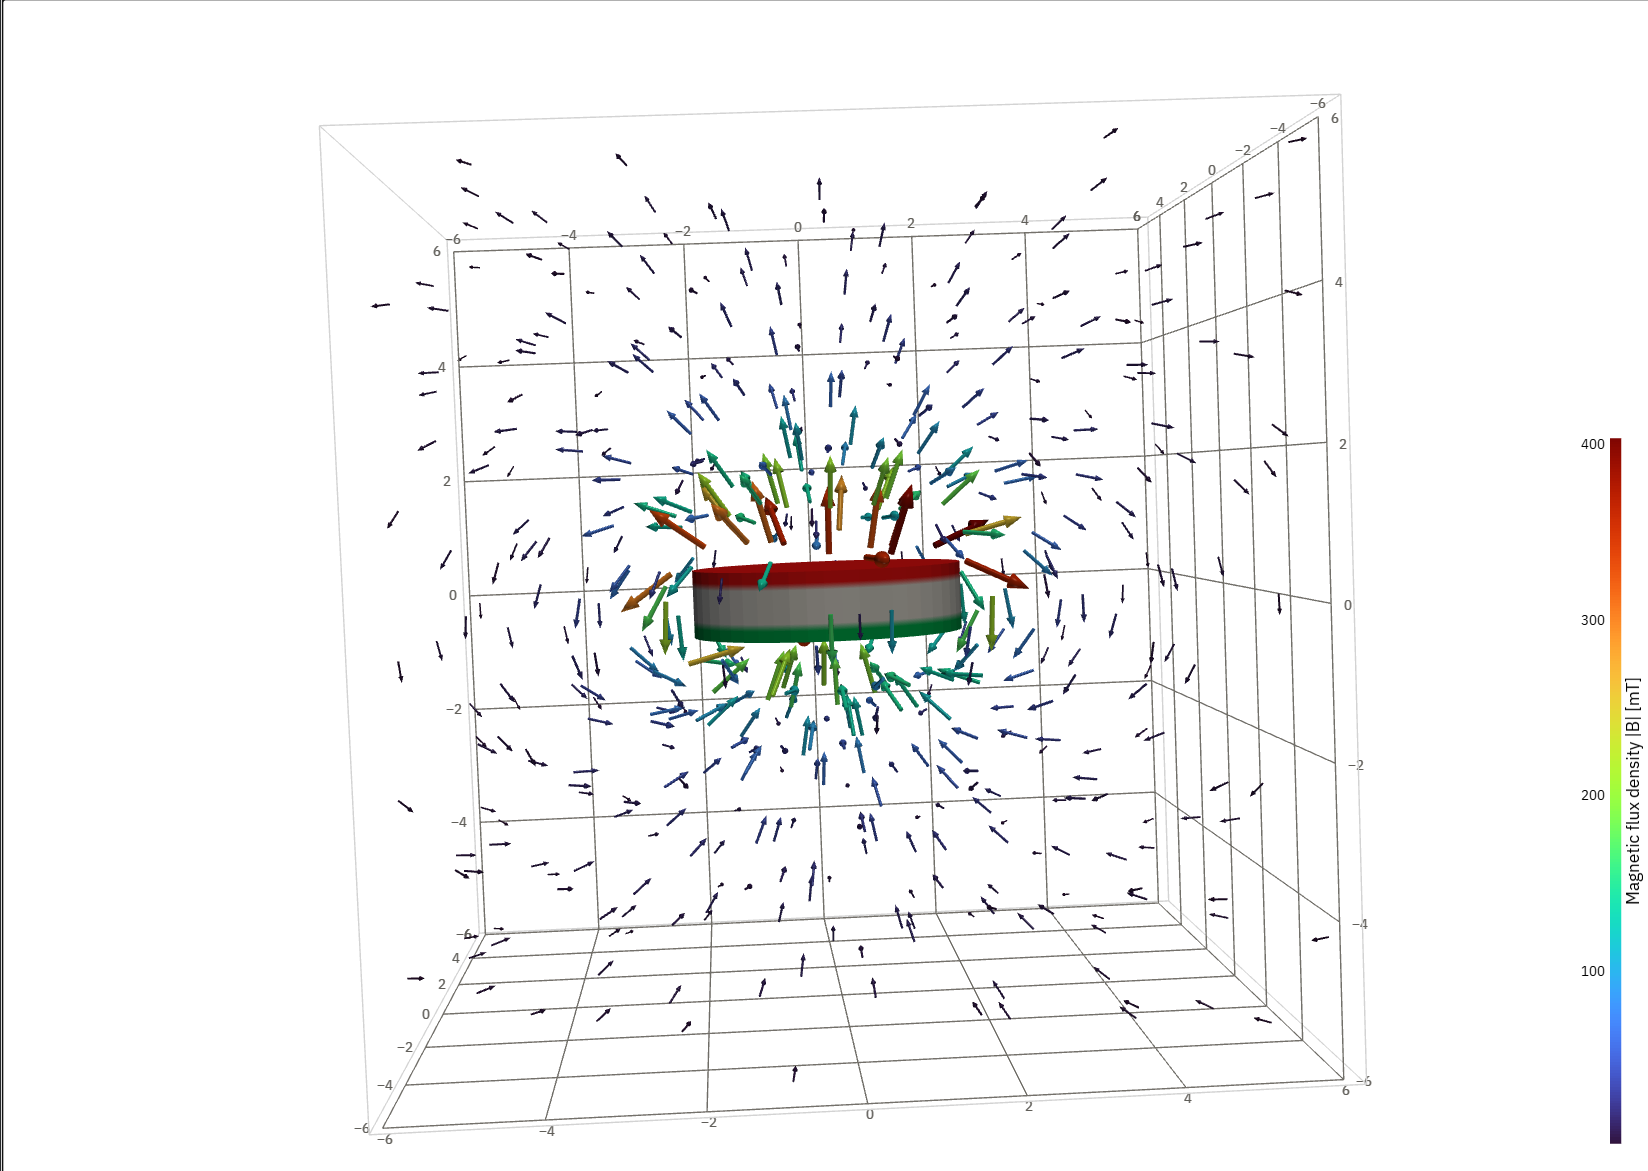